In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
import os

In [3]:
os.getcwd()

'/workspaces/solar_forecasting/notebooks'

In [4]:
from src.data_loader import load_data

ModuleNotFoundError: No module named 'src'

## About this Dataset

In [ ]:
data = load_data('data/interval_91_FT.csv')
# data = load_data('data/interval_41_SAT.csv')

In [ ]:
# Example: Load your actual dataset
# data = pd.read_csv('data/interval_91_FT.csv', parse_dates=['Unnamed: 0'], index_col='Unnamed: 0')

# For demonstration, assume 'data' is already loaded and indexed by datetime
# Filter data for July 1, 2020
daily_data = data['actual power']['2020-07-01']

# Create a professional plot
plt.figure(figsize=(12, 6))
plt.plot(daily_data, color='royalblue', linewidth=2, label='Actual Power')

# Title and labels
plt.title('Actual Power on July 1, 2020', fontsize=16, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Format x-axis for time
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))

# Rotate ticks and adjust layout
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plt.savefig('actual_power_july1.png', dpi=300)
plt.show()


NameError: name 'data' is not defined

In [ ]:
DAYS = 15

In [ ]:
# start_date = data.index.min()
start_date = pd.Timestamp('2020-07-01', tz='UTC-08:00')
end_date = start_date + pd.Timedelta(days=DAYS)
data = data[(data.index >= start_date) & (data.index < end_date)]

In [ ]:
start_date

Timestamp('2020-07-01 00:00:00-0800', tz='UTC-08:00')

In [ ]:
power_data = data[['actual power', 'reference power']]

In [ ]:
weather_data = data[['poa irradiance (array tilt)', 'ambient temperature', 'ghi', 'wind speed']]

In [ ]:
DAYS*24*4

1440

1 - Power generation data

In [ ]:
power_data.shape

(1440, 2)

✅ Same number of timestamps respect to the excepted number of timestamps:
2018: 365 days
2019: 365 days
2020: 366 days (leap year)
2021: 365 days

Total = 365 + 365 + 366 + 365 = 1,461 days

In [ ]:
# missing values
power_data.isnull().sum()

actual power       0
reference power    0
dtype: int64

In [ ]:
# nan values
power_data.isna().sum()

actual power       0
reference power    0
dtype: int64

There is no any presence of missing timestamps or nan values in the data of power.

In [ ]:
# missing values
weather_data.isnull().sum()

poa irradiance (array tilt)    0
ambient temperature            0
ghi                            0
wind speed                     0
dtype: int64

In [ ]:
# nan values
weather_data.isna().sum()

poa irradiance (array tilt)    0
ambient temperature            0
ghi                            0
wind speed                     0
dtype: int64

## Exploratory Analysis

In [ ]:
# We extract more features from DATE_TIME
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek

# Convert day of year to days of our study period (1-30)
days = data.index.dayofyear
data['day'] = days.map({days.unique()[i-1]:i for i in range(1, DAYS+1)})

# Step 1: Extract time values from the index as a Series
time_series = pd.Series(data.index.time, index=data.index)

# Step 2: Get sorted unique time values
unique_times = sorted(time_series.unique())

# Step 3: Create a mapping dictionary from time to interval label (1 to 96)
time_to_interval = {t: i+1 for i, t in enumerate(unique_times)}
# Step 4: Map the time values to interval labels
data['interval'] = time_series.map(time_to_interval)


In [ ]:
data['interval'].isnull().sum()

np.int64(0)

In [ ]:
# use data without missing values for the moment
df_na = data[~data.isna()]

## Data Correlation

<Axes: >

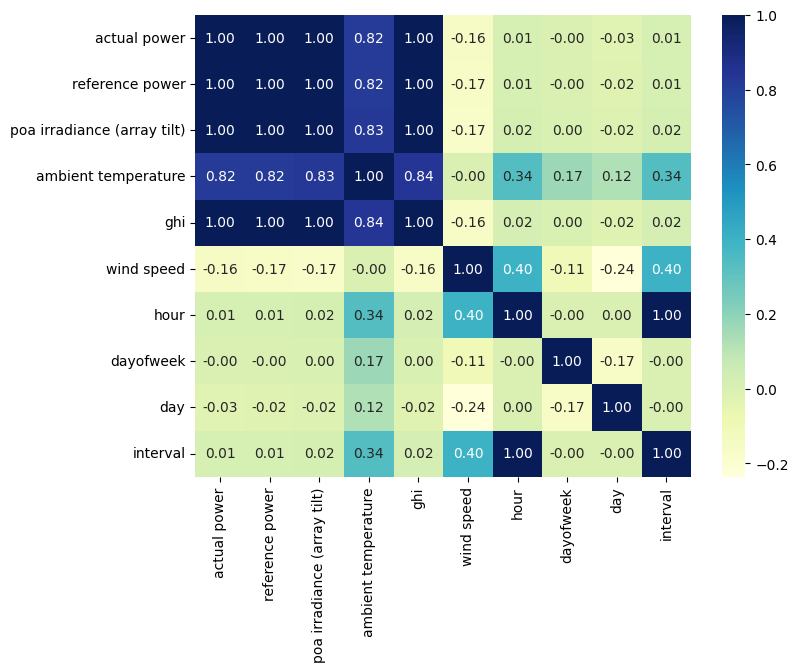

In [ ]:
# Let's see the correlation between our features
plt.figure(figsize=(8, 6))
sns.heatmap(df_na.corr(numeric_only=True), cmap='YlGnBu', fmt='.2f', annot=True)

In [ ]:
def plot_outliers(data, feature):
    """
    Plots outliers for a given feature in the provided data using the percentile method.
    Outliers are detected based on the specified feature and are determined by values
    falling outside the 1% and 99% percentiles for each interval.

    Parameters:
    - data (DataFrame): The input DataFrame containing the data.
    - feature (str): The name of the feature for which outliers will be detected and plotted.
    """

    df = data.copy()
    df = df.merge(df.groupby('interval')
                .quantile(0.01, numeric_only=True)[feature]\
                .rename('OUTLIERS_LOW'),
                 on='interval',
                 how='left')
    df = df.merge(df.groupby('interval')\
                .quantile(0.99, numeric_only=True)[feature]\
                .rename('OUTLIERS_HIGH'),
                 on='interval',
                 how='left')
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=df, y=feature, x='interval', hue='actual power',
                    palette='gray', alpha=0.1, legend=False)
    sns.scatterplot(data=df.query(f"`{feature}` > OUTLIERS_HIGH"), y=feature, x='interval')
    sns.scatterplot(data=df.query(f"`{feature}` < OUTLIERS_LOW"), y=feature, x='interval')

    plt.ylabel(feature)
    plt.xlabel('Hour of Day')
    ax.set_xticks([i for i in range(1, 97, 4)])
    ax.set_xticklabels([i for i in range(24)])
    ax.legend(['data', 'outliers_high', 'outliers_low'])

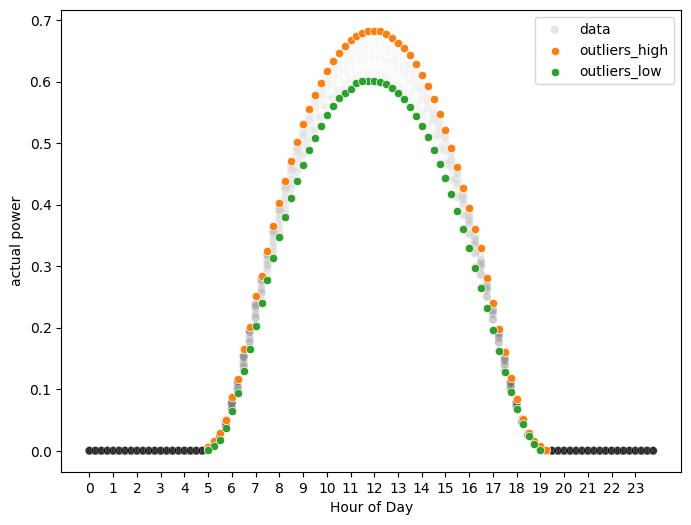

In [ ]:
plot_outliers(df_na, "actual power")

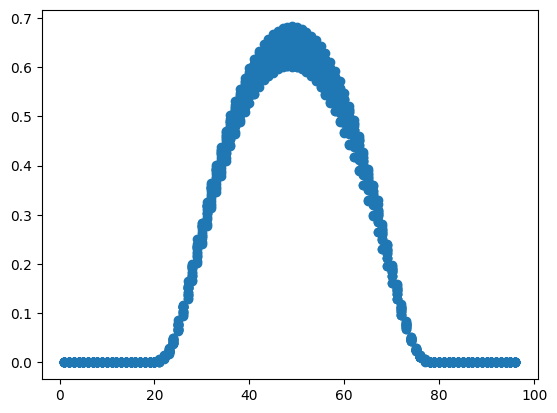

In [ ]:
plt.scatter(df_na['interval'], df_na['actual power'])

In [ ]:
data.isna().sum()

actual power                   0
reference power                0
poa irradiance (array tilt)    0
ambient temperature            0
ghi                            0
wind speed                     0
hour                           0
dayofweek                      0
day                            0
interval                       0
dtype: int64

In [ ]:
data.index = pd.to_datetime(data.index.strftime('%d-%m-%Y %H:%M'), format='%d-%m-%Y %H:%M')

In [ ]:
data_all = pd.concat([data.groupby(data.index).sum(numeric_only=True)[power_data.columns],
                       data.groupby(data.index).mean(numeric_only=True)[weather_data.columns]], axis=1)

# add datetime features
data_all['hour'] = data_all.index.hour
data_all['dayofweek'] = data_all.index.dayofweek
data_all['day'] = data_all.index.dayofyear
data_all['day'] = data_all.day.map({data_all.day.unique()[i-1]:i for i in range(1, DAYS+1)})
data_all['interval'] = data_all.index.time
data_all['interval'] = data_all.interval.map({unique_times[i-1]: i for i in range(1, len(unique_times)+1)})

In [ ]:
data_all

,actual power,reference power,poa irradiance (array tilt),ambient temperature,ghi,wind speed,hour,dayofweek,day,interval
2020-07-01 00:00:00,0.0,0.0,0.0,20.100000,0.0,2.166667,0,2,1,1
2020-07-01 00:15:00,0.0,0.0,0.0,19.900000,0.0,2.100000,0,2,1,2
2020-07-01 00:30:00,0.0,0.0,0.0,19.666667,0.0,2.033333,0,2,1,3
2020-07-01 00:45:00,0.0,0.0,0.0,19.433333,0.0,2.000000,0,2,1,4
2020-07-01 01:00:00,0.0,0.0,0.0,19.233333,0.0,1.900000,1,2,1,5
...,...,...,...,...,...,...,...,...,...,...
2020-07-15 22:45:00,0.0,0.0,0.0,23.800000,0.0,2.966667,22,2,15,92
2020-07-15 23:00:00,0.0,0.0,0.0,23.500000,0.0,2.833333,23,2,15,93
2020-07-15 23:15:00,0.0,0.0,0.0,23.266667,0.0,2.666667,23,2,15,94
2020-07-15 23:30:00,0.0,0.0,0.0,23.033333,0.0,2.566667,23,2,15,95


In [ ]:
day = 96 # 24*4 (for each 15min intervall)
# shift all data by 1 day so that each features sample
# corresponds to the next day AC_POWER generated
target = data_all['actual power'].shift(-day).dropna()
features = data_all[~data_all['actual power'].shift(-day).isna()]

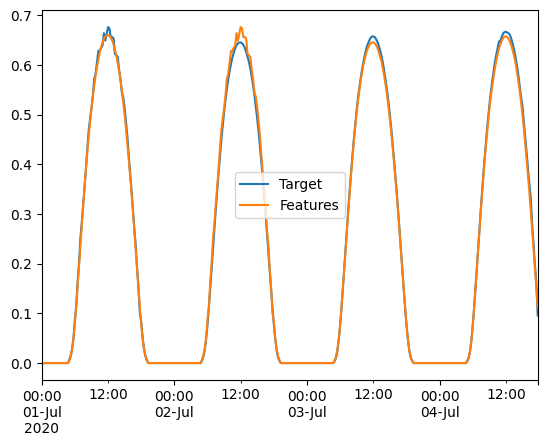

In [ ]:
target.iloc[:360].plot(label='Target')
features['actual power'].iloc[:360].plot(label='Features')
plt.legend()

In [ ]:
power_features = power_data.columns
weather_features = weather_data.columns

In [ ]:
# last 4 days will be reserved for testing
split_datetime = -day*4
x_train = features.iloc[:split_datetime]
x_test = features.iloc[split_datetime:]
y_train = target[:split_datetime]
y_test = target[split_datetime:]

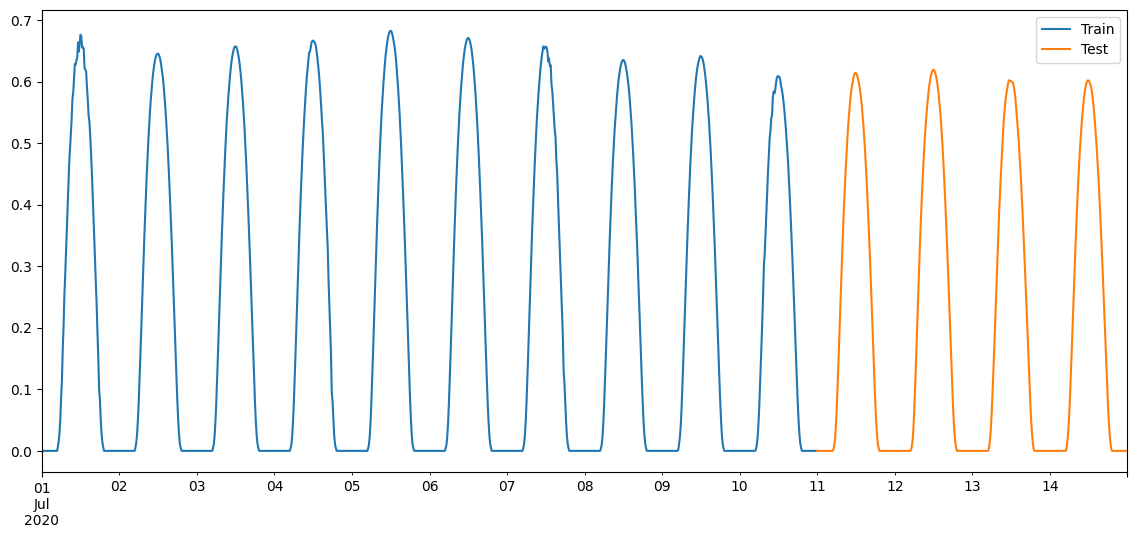

In [ ]:
# Plot AC power training and testing date splits
_ = pd.DataFrame(y_train) \
    .rename(columns={'actual power': 'Train'}) \
    .join(pd.DataFrame(y_test).rename(columns={'actual power': 'Test'}), how='outer') \
    .plot(figsize=(14,6))

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute the accuracy errors : MAE, RMSE, R2 score.
def get_prediction_errors(y_true, y_pred):
    R2_score = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"R2 score: {R2_score}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    return [R2_score, mae, rmse]

In [ ]:
def plot_predictions(test, predicted):
    plt.figure(figsize=(14,6))
    plt.plot(test, label='Actual AC power', linewidth=3)
    plt.plot(predicted, label='Predicted AC power', linewidth=3)
    plt.xlabel('Time')
    plt.ylabel('AC Power Generated')
    plt.legend()
    plt.show()

In [ ]:
def plot_forecast_day(test, predicted, forecast_pred, title = None):
    date_range = pd.date_range(start="2020-07-15 23:45:00", periods=len(forecast_pred), freq='15min')
    future_days = pd.DataFrame({'Date': date_range, 'Forecast': forecast_pred})
    future_days.index = future_days["Date"]
    plt.figure(figsize=(14,6))
    plt.plot(test, label='Actual AC power', linewidth=3)
    plt.plot(predicted, label='Predicted AC power', linewidth=3)
    plt.plot(future_days["Forecast"], label='Forecasted AC power', linewidth=3)
    plt.xlabel('Time')
    plt.ylabel('AC Power Generated')
    plt.legend()
    if title:
        plt.title(title)
    plt.show()

## Building ML Models

### 1- XGBoost :

In [ ]:
import xgboost as xgb

xgboost = xgb.XGBRegressor(n_estimators=200,
                           learning_rate=0.01,
                           max_depth=5,
                           min_child_weight=10,
                           base_score=0.5
                          )
xgboost.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=0)

,objective,'reg:squarederror'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


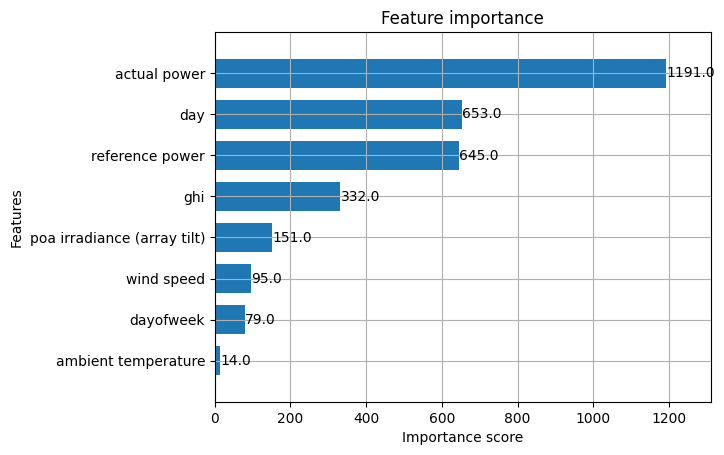

In [ ]:
_ = xgb.plot_importance(xgboost, height=0.7)

In [ ]:
predicted = xgboost.predict(x_test)
results = pd.concat([y_test, pd.Series(predicted, index=y_test.index)], axis=1)
results.index = data_all.index[-4*day:]
results.columns = ["Actual", "Predicted"]

In [ ]:
xgb_errors = get_prediction_errors(results["Actual"], results["Predicted"])

R2 score: 0.9535036842181162
MAE: 0.046052984024679104
RMSE: 0.05164487740526043


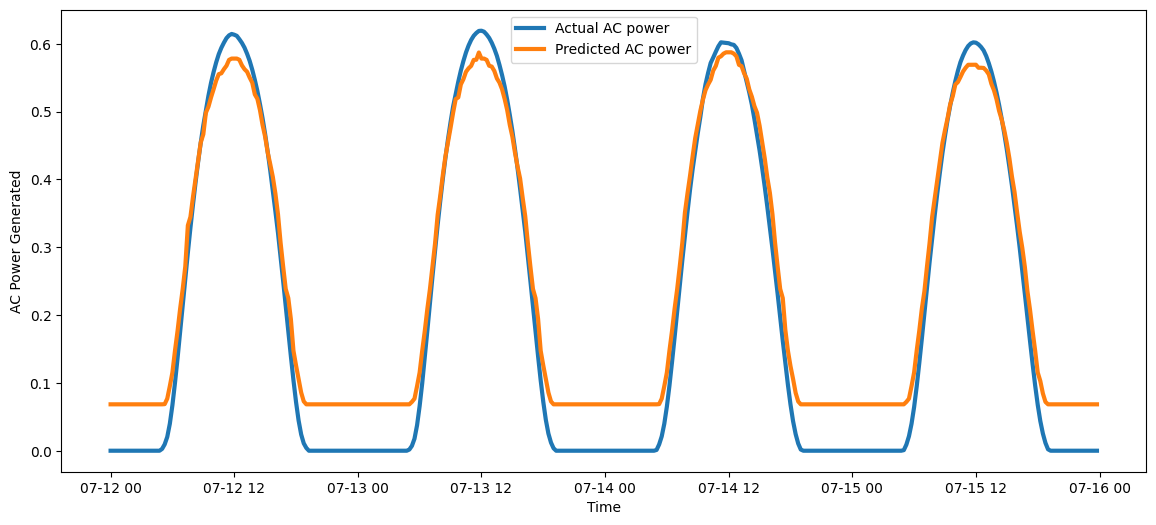

In [ ]:
plot_predictions(results["Actual"], results["Predicted"])

### Forecast Next Future Day

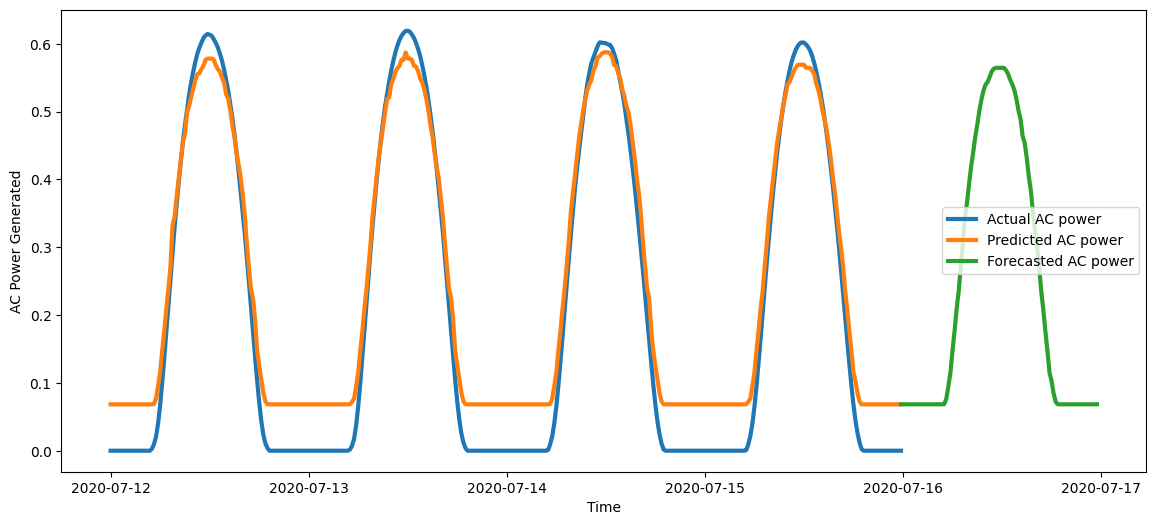

In [ ]:
last_day = data_all["2020-07-15 00:00:00":]
last_day_pred = xgboost.predict(last_day)
plot_forecast_day(results["Actual"], results["Predicted"], last_day_pred)

In [ ]:
results["Actual"]

2020-07-12 00:00:00    0.0
2020-07-12 00:15:00    0.0
2020-07-12 00:30:00    0.0
2020-07-12 00:45:00    0.0
2020-07-12 01:00:00    0.0
                      ... 
2020-07-15 22:45:00    0.0
2020-07-15 23:00:00    0.0
2020-07-15 23:15:00    0.0
2020-07-15 23:30:00    0.0
2020-07-15 23:45:00    0.0
Name: Actual, Length: 384, dtype: float64

In [ ]:
last_day = data_all["2020-07-15 00:00:00":]
last_day_pred = xgboost.predict(last_day)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=7)
rf.fit(x_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


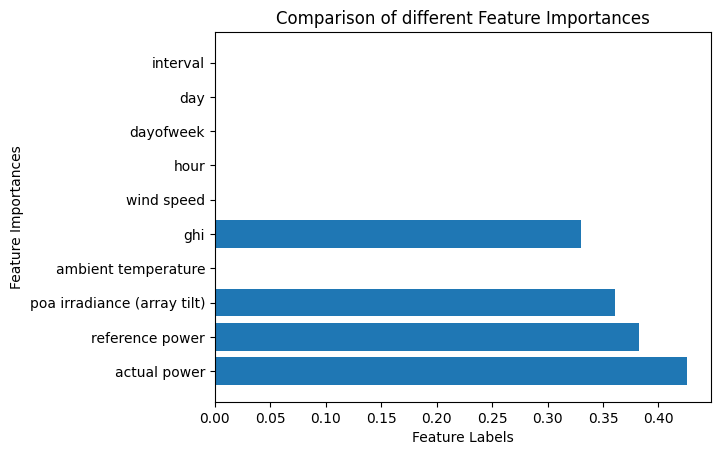

In [ ]:
feature_importance = rf.feature_importances_

# Normalizing the individual importances
feature_importance_normalized = np.std([tree.feature_importances_ for tree in
                                        rf.estimators_],
                                        axis=0)

plt.barh(x_train.columns, feature_importance_normalized)
plt.xlabel('Feature Labels')
plt.ylabel('Feature Importances')
plt.title('Comparison of different Feature Importances')
plt.show()

In [ ]:
results["Predicted"] = rf.predict(x_test)
rf_errors = get_prediction_errors(results["Actual"], results["Predicted"])

R2 score: 0.9985523469590722
MAE: 0.005199086157815042
RMSE: 0.009112766099473186


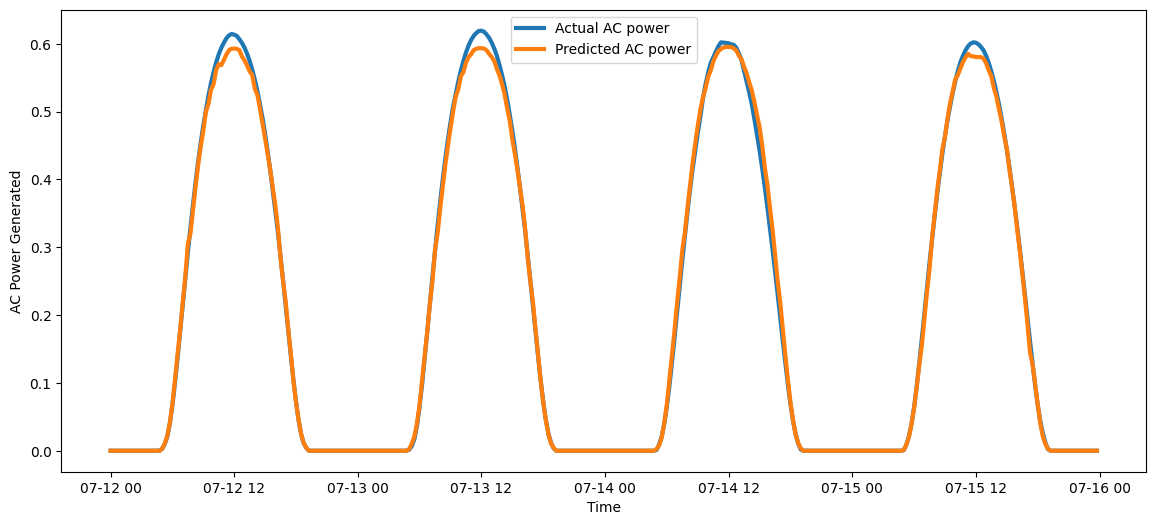

In [ ]:
plot_predictions(results["Actual"], results["Predicted"])

### Forecast Next Future Day

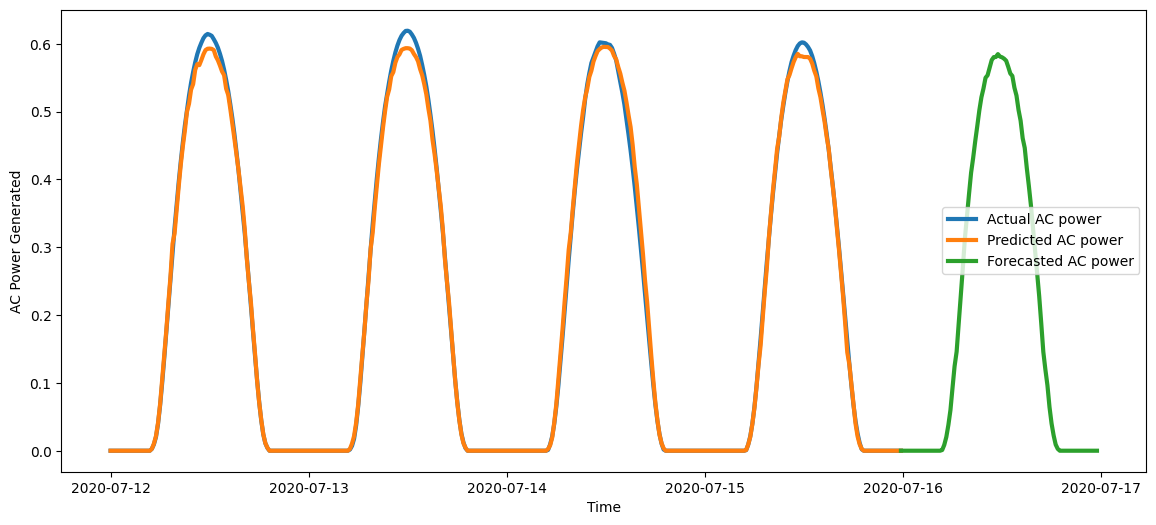

In [ ]:
last_day_pred = rf.predict(last_day)
plot_forecast_day(results["Actual"], results["Predicted"], last_day_pred)

## LSTM Model

### 1- Data scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def scale_data(data):
    features = data_all.iloc[:, 1:]
    target = data_all.iloc[:, 0]
    x_scaler = MinMaxScaler()
    X = pd.DataFrame(x_scaler.fit_transform(features))

    y_scaler = MinMaxScaler()
    Y = pd.DataFrame(y_scaler.fit_transform(target.values.reshape(-1, 1)))

    scaled_data = pd.concat([Y, X], axis=1)
    scaled_data.columns = data.columns

    return scaled_data, y_scaler

In [ ]:
scaled_data, y_scaler = scale_data(data_all)

### 2- Construct Window Data

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

def create_lstm_data(data, past_days, future_days):
    """
    Create fixed-shape LSTM windows using deterministic sliding windows.
    - X arrays shape: (n_windows, train_size, n_features)
    - y arrays shape: (n_windows, test_size)
    """
    test_size = future_days * day
    train_size = past_days * day
    n = len(data)

    if n < train_size + test_size:
        raise ValueError("Not enough samples for requested past_days/future_days")

    # number of non-overlapping windows available
    max_windows = (n - train_size) // test_size
    if max_windows <= 0:
        raise ValueError("Not enough windows available given test_size/train_size")

    n_splits = min(30, max_windows)

    # ensure at least one training window; reserve last `future_days` windows for test
    cutoff = max(1, n_splits - future_days)

    X_train, y_train = [], []
    X_test, y_test = [], []

    for k in range(n_splits):
        train_end = train_size + k * test_size - 1
        train_start = train_end - train_size + 1
        test_start = train_end + 1
        test_end = test_start + test_size - 1

        if test_end >= n:
            break

        Xw = data.iloc[train_start: train_end + 1].values  # shape: train_size x n_features
        yw = data['actual power'].iloc[test_start: test_end + 1].values  # length: test_size

        if k < cutoff:
            X_train.append(Xw)
            y_train.append(yw)
        else:
            X_test.append(Xw)
            y_test.append(yw)

    if len(X_train) == 0:
        raise ValueError("No training windows created. Reduce future_days or provide more data.")

    return np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

In [ ]:
X_train, Y_train, X_test, Y_test = create_lstm_data(scaled_data, 3, 1)

### 3- Build & train LSTM

In [ ]:
import tensorflow as tf
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

lstm_model = Sequential()
lstm_model.add(LSTM(256, return_sequences=True, kernel_initializer=tf.initializers.zeros() , input_shape=X_train.shape[1:]))
lstm_model.add(Dropout(0.3))
lstm_model.add(LSTM(256, kernel_initializer=tf.initializers.zeros()))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(day))
lstm_model.summary()

/workspaces/solar_forecasting/env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 288, 256)       │       273,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 288, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 96)             │        24,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 823,392 (3.14 MB)

 Trainable params: 823,392 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=20,
                                                    mode='min',
                                                    restore_best_weights=True)

lstm_model.compile(optimizer="adam", loss="MSE")
lstm_model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=200, callbacks=[early_stopping], verbose=0)

<Axes: >

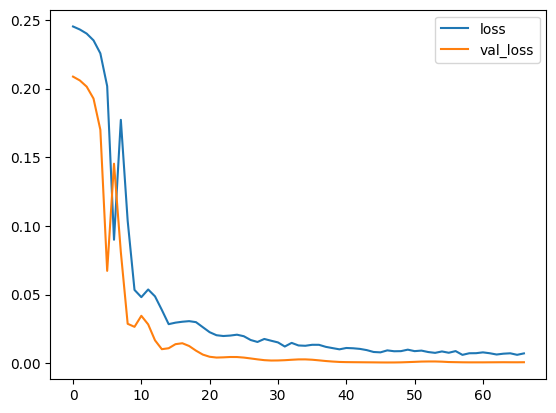

In [ ]:
history = pd.DataFrame(lstm_model.history.history)
history.plot()

In [ ]:
# construct 3 days window data to predict the AC power of last 3 days
input_test_day_1 = np.array(scaled_data.iloc[-6*day:-3*day, :])
input_test_day_2 = np.array(scaled_data.iloc[-5*day:-2*day, :])
input_test_day_3 = np.array(scaled_data.iloc[-3*day:, :])
input_test_days = np.array([input_test_day_1, input_test_day_2, input_test_day_3])

In [ ]:

# Predict with LSTM
lstm_predictions = lstm_model.predict(input_test_days)

# Select last 3 days of actual data
y_test = data_all.iloc[-3*day:, 0]

# Inverse transform predictions
y_pred = y_scaler.inverse_transform(lstm_predictions.reshape(-1, 1)).flatten()

# # Remove NaNs from both arrays
# mask = ~np.isnan(y_test) & ~np.isnan(y_pred)
# y_test_clean = y_test[mask]
# y_pred_clean = y_pred[mask]

# Compute errors safely
lstm_errors = get_prediction_errors(y_test, y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
R2 score: 0.9957173511015991
MAE: 0.012405934899611316
RMSE: 0.015621956976507083


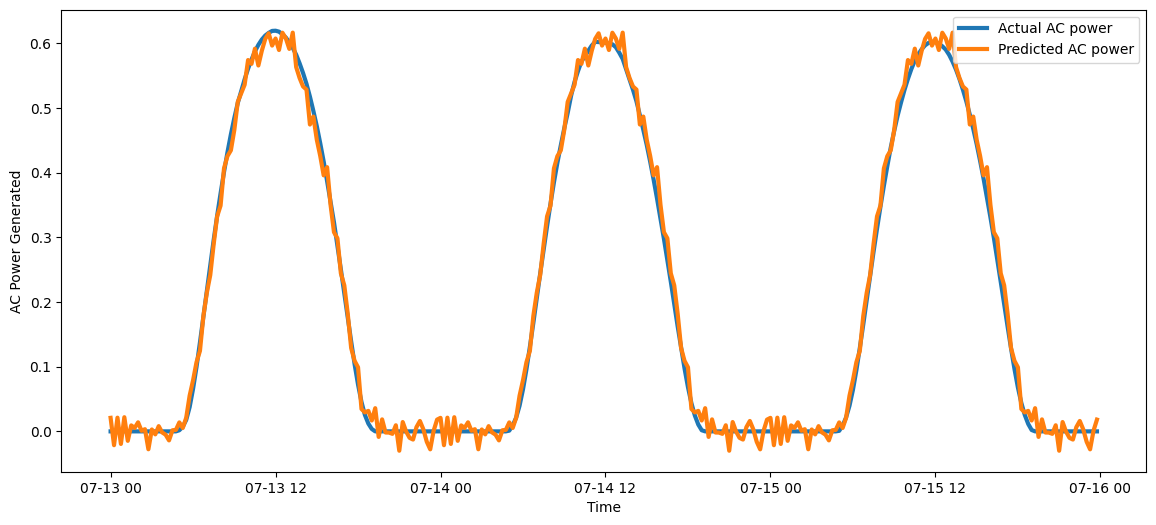

In [ ]:
results = pd.concat([y_test, pd.Series(y_pred, index=y_test.index)], axis=1)
results.index = data_all.index[-3*day:]
results.columns = ["Actual", "Predicted"]
plot_predictions(results["Actual"], results["Predicted"])

### Forecast Next Future Day

In [ ]:
last_day = np.array(scaled_data)[-3*day:, :]
last_day_arr = np.array([last_day])
future_day_pred = lstm_model.predict(last_day_arr)
future_pred = y_scaler.inverse_transform(future_day_pred.reshape(day, 1)).reshape(-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


In [ ]:
stats = pd.DataFrame([xgb_errors, rf_errors, lstm_errors],
                     columns=["R2 score", "MAE", "RMSE"],
                     index=["XGBoost", "RandomForest", "LSTM"]
                     )

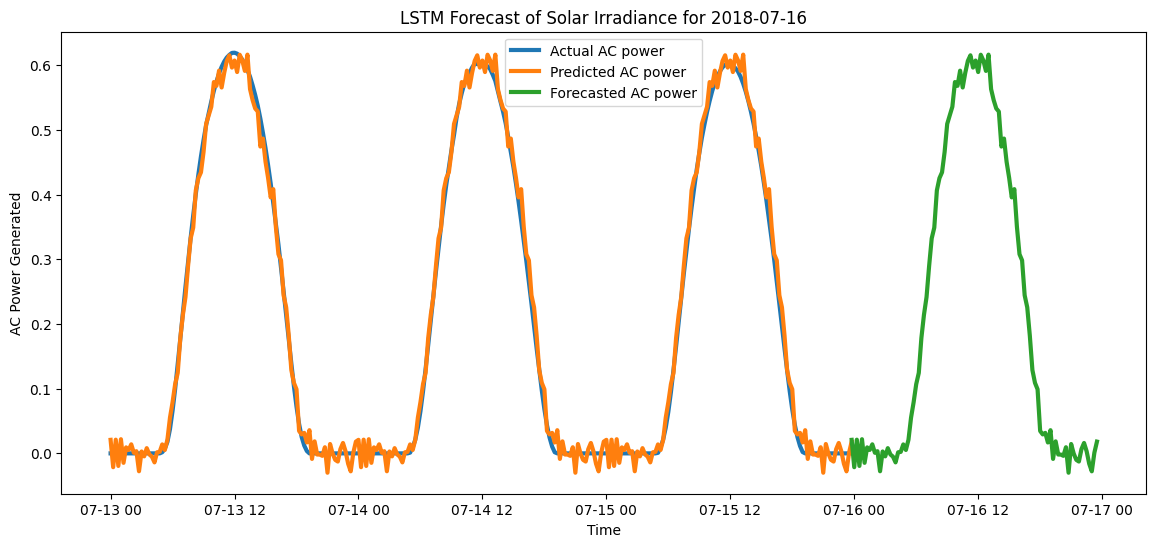

final results:


,R2 score,MAE,RMSE
XGBoost,0.953504,0.046053,0.051645
RandomForest,0.998552,0.005199,0.009113
LSTM,0.995717,0.012406,0.015622


In [ ]:
plot_forecast_day(results["Actual"], results["Predicted"], future_pred, title="LSTM Forecast of Solar Irradiance for 2018-07-16")
print('final results:')
stats.head()